# *Risk Analyst I — Fraud Detection Case*
### Kaleo Martins

## Exploração Inicial dos Dados

Antes de iniciar a análise detalhada, foi realizada uma exploração inicial do dataset bruto com o objetivo de entender sua estrutura e principais características.

Em projetos de Data Science, é comum começar definindo as perguntas que queremos responder. No entanto, neste caso, as perguntas já estão bem definidas pelo próprio case. Assim, a análise é direcionada diretamente para extrair insights alinhados a esses objetivos.

Nesta etapa inicial, buscamos:
- entender a distribuição das transações ao longo do tempo
- comparar o comportamento entre transações legítimas e fraudulentas
- identificar sinais iniciais que possam indicar padrões suspeitos

Essa exploração serve como base para a identificação dos comportamentos fraudulentos analisados nas próximas seções.

# - Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, precision_score, recall_score, f1_score,roc_auc_score, ConfusionMatrixDisplay )
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Carregamento & Limpeza

In [2]:
df = pd.read_csv('transactional-sample.csv')

# Parse dates
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Boolean CBK
df['has_cbk'] = df['has_cbk'].astype(str).str.upper().map({'TRUE': True, 'FALSE': False})

# Device ID como string (pode ser nulo) e tirar espaços
df['device_id'] = df['device_id'].astype(str).replace('nan', None)
df['device_id'] = (
    df['device_id']
    .astype(str)
    .str.strip()
    .str.replace('.0', '', regex=False) )

# Features de tempo
df['hour']    = df['transaction_date'].dt.hour
df['weekday'] = df['transaction_date'].dt.dayofweek
df['date']    = df['transaction_date'].dt.date

df = df.sort_values('transaction_date').reset_index(drop=True)

print(f"Total transactions : {len(df):,}")
print(f"Fraud (cbk=True)   : {df['has_cbk'].sum():,}  ({df['has_cbk'].mean()*100:.1f}%)")
print(f"Date range         : {df['transaction_date'].min().date()} → {df['transaction_date'].max().date()}")
print(f"Unique users       : {df['user_id'].nunique():,}")
print(f"Unique merchants   : {df['merchant_id'].nunique():,}")
print(f"Missing device_id  : {(df['device_id'].isna() | (df['device_id']=='None')).sum():,}")
print()
print(df.describe())

Total transactions : 3,199
Fraud (cbk=True)   : 391  (12.2%)
Date range         : 2019-11-01 → 2019-12-01
Unique users       : 2,704
Unique merchants   : 1,756
Missing device_id  : 830

       transaction_id   merchant_id       user_id  \
count    3.199000e+03   3199.000000   3199.000000   
mean     2.132200e+07  48771.128790  50891.077212   
min      2.132040e+07     16.000000      6.000000   
25%      2.132120e+07  23426.000000  24267.500000   
50%      2.132200e+07  48752.000000  52307.000000   
75%      2.132280e+07  73915.000000  76837.000000   
max      2.132360e+07  99799.000000  99974.000000   
std      9.236161e+02  29100.360839  29515.282827   

                    transaction_date  transaction_amount         hour  \
count                           3199         3199.000000  3199.000000   
mean   2019-11-22 12:47:02.242350336          767.812904    15.495780   
min       2019-11-01 01:27:15.811098            1.220000     0.000000   
25%    2019-11-18 18:35:57.557812992        

# EDA Geral

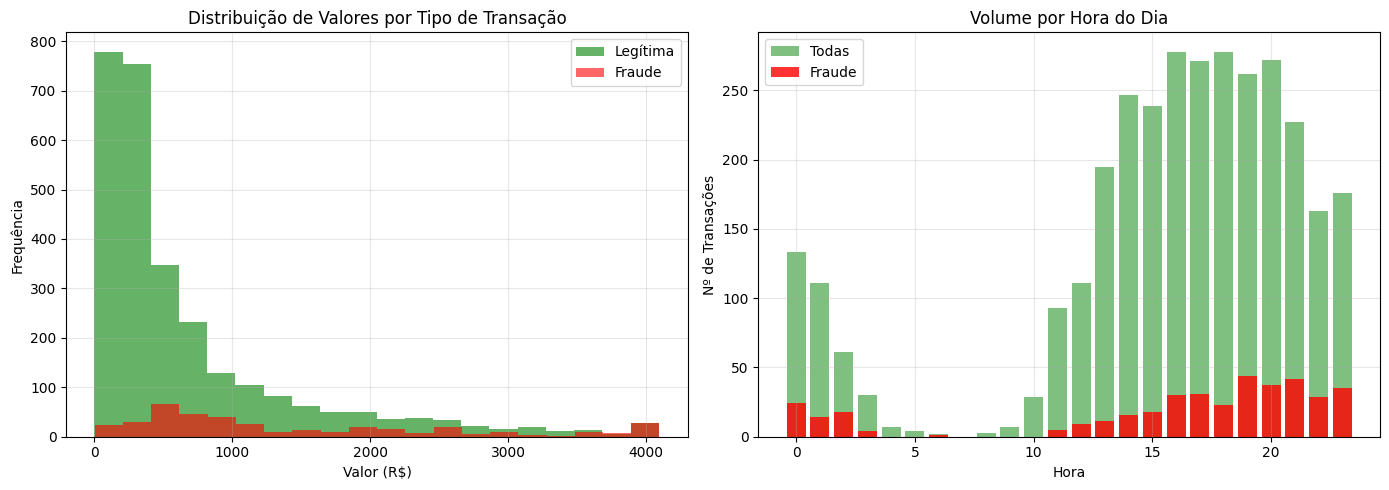

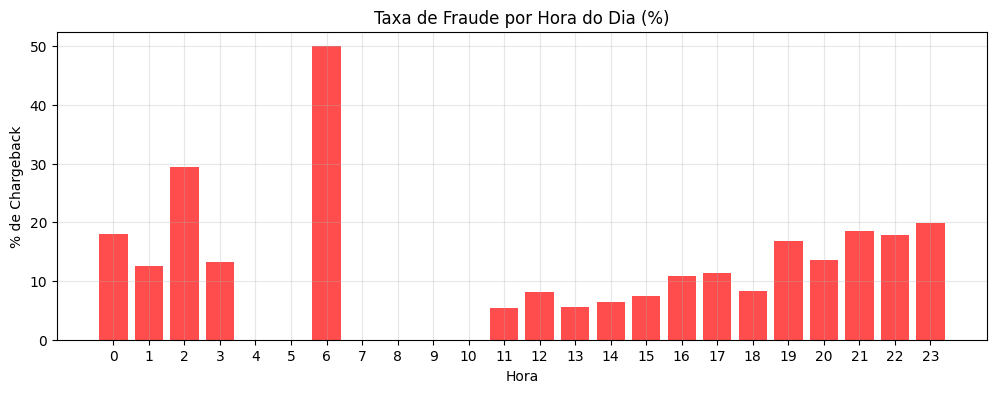

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de valores — fraude vs legítimo
axes[0].hist(
    df[~df["has_cbk"]]["transaction_amount"],
    bins=20,
    alpha=0.6,
    color="green",
    label="Legítima",
)
axes[0].hist(
    df[df["has_cbk"]]["transaction_amount"],
    bins=20,
    alpha=0.6,
    color="red",
    label="Fraude",
)
axes[0].set_title("Distribuição de Valores por Tipo de Transação")
axes[0].set_xlabel("Valor (R$)")
axes[0].set_ylabel("Frequência")
axes[0].legend()


# Transações por hora do dia
hour_all = df.groupby("hour").size()
hour_fraud = df[df["has_cbk"]].groupby("hour").size()
axes[1].bar(
    hour_all.index, hour_all.values, alpha=0.5, color="green", label="Todas"
)
axes[1].bar(
    hour_fraud.index, hour_fraud.values, alpha=0.8, color="red", label="Fraude"
)
axes[1].set_title("Volume por Hora do Dia")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Nº de Transações")
axes[1].legend()

plt.tight_layout()
plt.show()

# Taxa de fraude por hora
fraud_rate_by_hour = df.groupby("hour")["has_cbk"].mean() * 100
plt.figure(figsize=(12, 4))
plt.bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values, color="red", alpha=0.7)
plt.title("Taxa de Fraude por Hora do Dia (%)")
plt.xlabel("Hora")
plt.ylabel("% de Chargeback")
plt.xticks(range(24))
plt.show()


## Identificando Comportamentos Suspeitos

### Padrão 1 — Velocity Attack

**O que é:** O mesmo usuário realizou múltiplas transações em um intervalo menor que 30 minutos.

**Por que é suspeito:** Em transações legítimas, um cliente raramente compra 5+ vezes no mesmo 
intervalo de meia hora. Fraudadores operam em burst e aproveitam uma janela antes que o cartão 
seja bloqueado pelo emissor.

**Impacto:** Usuários com burst rate elevado têm taxa de CBK significativamente acima da média 
do dataset. O user_id 11750, por exemplo, realizou 26 transações com cartões distintos no mesmo 
dispositivo, padrão impossível em uso legítimo.

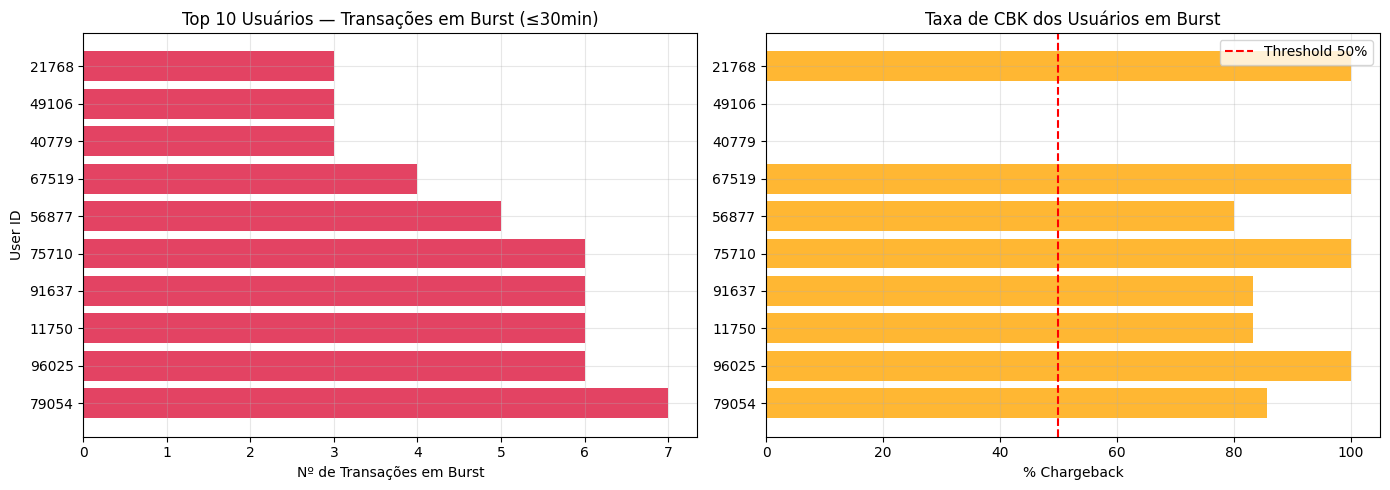

 user_id  burst_count  cbk_rate  total_amount
   79054            7  0.857143      15210.32
   96025            6  1.000000      14540.96
   11750            6  0.833333       3762.47
   91637            6  0.833333       4810.48
   75710            6  1.000000       2288.97
   56877            5  0.800000       4016.92
   67519            4  1.000000      11576.05
   40779            3  0.000000       8161.77
   49106            3  0.000000      12099.09
   21768            3  1.000000       3030.90


In [4]:
# ── PADRÃO 1: Múltiplas transações do mesmo usuário em curto intervalo ──

df_v = df.sort_values(['user_id', 'transaction_date'])
df_v['prev_date'] = df_v.groupby('user_id')['transaction_date'].shift(1)
df_v['gap_min']   = (df_v['transaction_date'] - df_v['prev_date']).dt.total_seconds() / 60

burst_users = (
    df_v[df_v['gap_min'] <= 30]
    .groupby('user_id')  
    .agg(burst_count=('transaction_id', 'count'),
         cbk_rate=('has_cbk', 'mean'),
         total_amount=('transaction_amount', 'sum'))
    .reset_index()  
    .sort_values('burst_count', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(burst_users['user_id'].astype(str),
             burst_users['burst_count'], color='crimson', alpha=0.8)
axes[0].set_title('Top 10 Usuários — Transações em Burst (≤30min)')
axes[0].set_xlabel('Nº de Transações em Burst')
axes[0].set_ylabel('User ID')

axes[1].barh(burst_users['user_id'].astype(str),
             burst_users['cbk_rate'] * 100, color='orange', alpha=0.8)
axes[1].set_title('Taxa de CBK dos Usuários em Burst')
axes[1].set_xlabel('% Chargeback')
axes[1].axvline(x=50, color='red', linestyle='--', label='Threshold 50%')
axes[1].legend()

plt.tight_layout()
plt.show()
print(burst_users.to_string(index=False))

### Padrão 2 — Card Testing

Fraudadores frequentemente utilizam micro-transações (valores baixos) para testar a validade de cartões antes de realizar compras de maior valor.

Para identificar esse comportamento, foram analisadas sequências de transações por usuário, buscando padrões onde:
- uma micro-transação (< R$10) é seguida por uma transação de valor mais alto
- ambas ocorrem em um curto intervalo de tempo (até 30 minutos)

Os resultados, no entanto, revelaram um achado contra-intuitivo: a taxa de CBK 
em micro-transações foi de **1.9%**  abaixo da média geral de 12.2% do dataset.

Isso não invalida a hipótese. Há duas explicações plausíveis:

1. **Viés de seleção no dataset**: fraudadores que fazem card testing bem-sucedido 
   raramente geram chargeback na própria micro-transação, o chargeback ocorre na 
   transação de valor alto que vem depois. O sinal real está na sequência, não na 
   micro-txn isolada.

2. **Volume insuficiente**: apenas 52 micro-transações (1.6% do dataset) amostra 
   pequena demais para conclusão estatística robusta.

A regra de bloqueio para card testing continua justificada como medida preventiva. 
Em produção, o sinal seria validado com um dataset de maior volume e com a 
sequência completa (micro-txn → txn alta) rastreada no mesmo user_id.

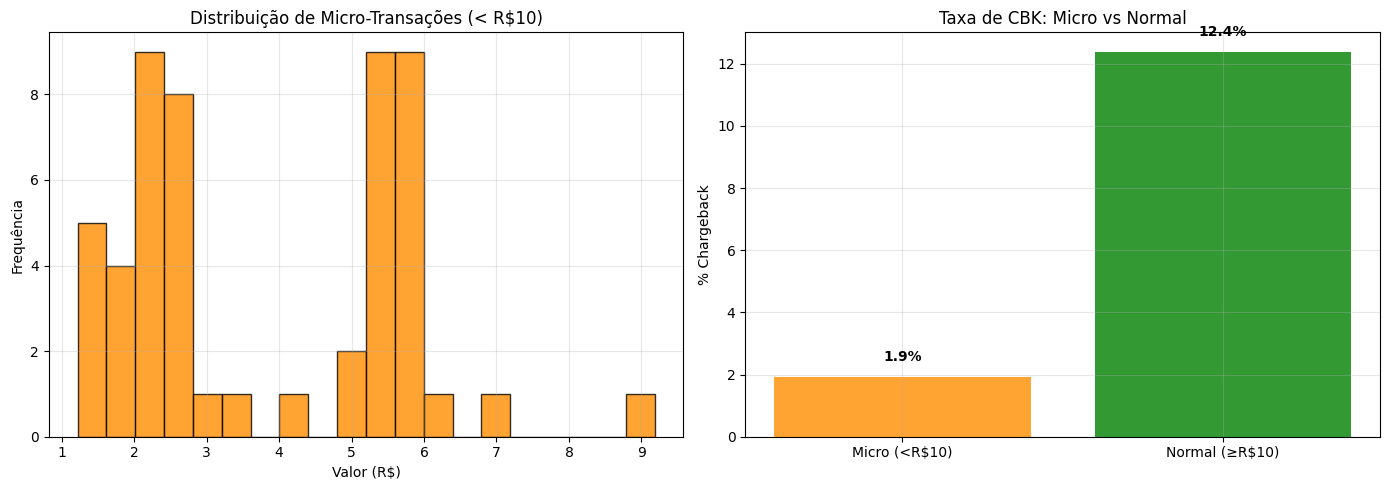

Sequências de card testing detectadas:

  User 84486:
          transaction_date  transaction_amount  has_cbk
2019-11-01 10:23:50.555604                1.55    False
2019-11-17 08:40:43.924601                1.22    False
2019-11-18 14:39:31.744189                1.92    False

  User 50105:
          transaction_date  transaction_amount  has_cbk
2019-11-03 18:25:07.144038                2.56    False
2019-11-03 18:34:54.311401                2.42    False

  User 92926:
          transaction_date  transaction_amount  has_cbk
2019-11-10 21:11:49.087007                5.43    False

  User 6024:
          transaction_date  transaction_amount  has_cbk
2019-11-15 18:32:20.753779                5.39    False
2019-11-15 18:35:48.628972               10.79    False

  User 27916:
          transaction_date  transaction_amount  has_cbk
2019-11-17 11:16:42.252558                 6.3    False


In [5]:
# ── PADRÃO 2: Micro-transações seguidas de valores maiores ──

micro = df[df['transaction_amount'] < 10].copy()
micro_users = micro['user_id'].unique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de valores das micro-transações
axes[0].hist(micro['transaction_amount'], bins=20,
             color='darkorange', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribuição de Micro-Transações (< R$10)')
axes[0].set_xlabel('Valor (R$)')
axes[0].set_ylabel('Frequência')

# CBK rate: micro vs normal
cbk_micro  = micro['has_cbk'].mean() * 100
cbk_normal = df[df['transaction_amount'] >= 10]['has_cbk'].mean() * 100
axes[1].bar(['Micro (<R$10)', 'Normal (≥R$10)'],
            [cbk_micro, cbk_normal],
            color=['darkorange', 'green'], alpha=0.8)
axes[1].set_title('Taxa de CBK: Micro vs Normal')
axes[1].set_ylabel('% Chargeback')
for i, v in enumerate([cbk_micro, cbk_normal]):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar sequências de card testing
print("Sequências de card testing detectadas:")
for uid in micro_users[:5]:
    user_txns = df[df['user_id'] == uid].sort_values('transaction_date')
    print(f"\n  User {uid}:")
    print(user_txns[['transaction_date','transaction_amount','has_cbk']].to_string(index=False))

### Padrão 3 — Múltiplos Cartões no Mesmo Dispositivo

Aqui o padrão é bem direto: um mesmo device sendo usado com vários cartões diferentes.

No uso normal, uma pessoa pode ter 1 ou 2 cartões. Quando começa a aparecer 4, 5, 10 cartões no mesmo dispositivo, isso já foge completamente do comportamento esperado.

Esse tipo de padrão é muito comum em fraude, principalmente quando alguém testa vários cartões em sequência usando o mesmo ambiente.

Os resultados mostram que dispositivos com múltiplos cartões tendem a apresentar taxas significativamente mais altas de chargeback.

O gráfico de dispersão reforça essa relação: à medida que o número de cartões por dispositivo aumenta, a taxa de fraude também cresce, indicando forte correlação entre esse comportamento e atividade fraudulenta.

Esse padrão é um dos sinais mais fortes de fraude em ambientes CNP, sendo frequentemente utilizado como regra direta em sistemas antifraude.

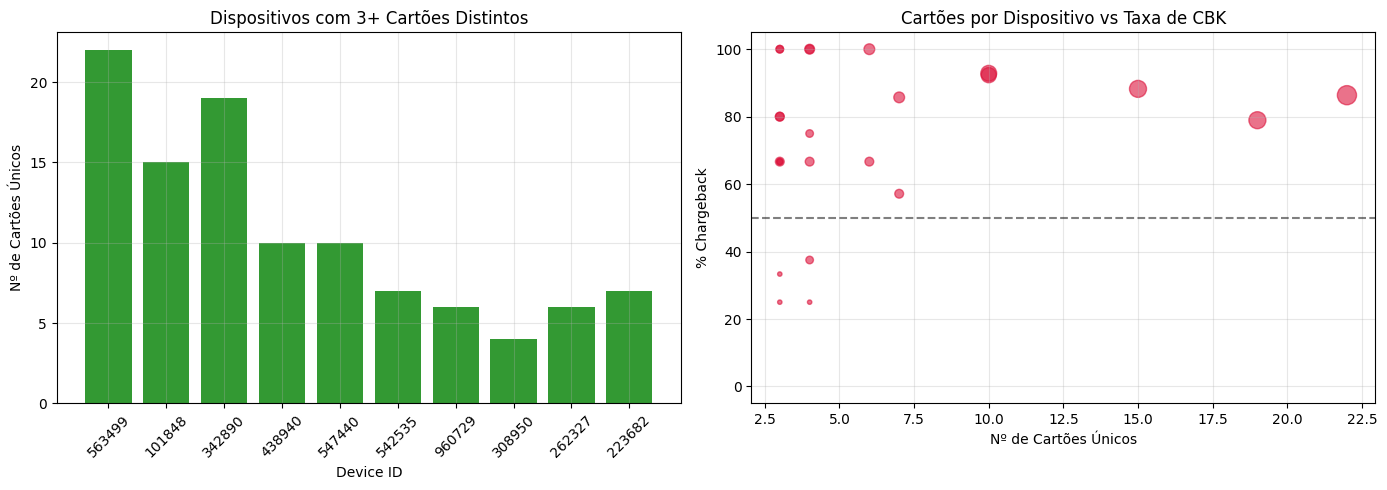

device_id  unique_cards  unique_users  total_txns  cbk_count  cbk_rate
   563499            22             1          22         19  0.863636
   101848            15             1          17         15  0.882353
   342890            19             1          19         15  0.789474
   438940            10             1          14         13  0.928571
   547440            10             1          13         12  0.923077
   542535             7             1           7          6  0.857143
   960729             6             1           6          6  1.000000
   308950             4             1           5          5  1.000000
   262327             6             1           6          4  0.666667
   223682             7             1           7          4  0.571429


In [6]:
# ── PADRÃO 3: Device fingerprint com múltiplos cartões ──

has_device = df['device_id'].notna() & (df['device_id'] != 'None')
dev_stats = (
    df[has_device]
    .groupby('device_id')
    .agg(
        unique_cards=('card_number', 'nunique'),
        unique_users=('user_id', 'nunique'),
        total_txns=('transaction_id', 'count'),
        cbk_count=('has_cbk', 'sum')
    )
    .reset_index()
)
dev_stats['cbk_rate'] = dev_stats['cbk_count'] / dev_stats['total_txns']
multi_card = dev_stats[dev_stats['unique_cards'] >= 3].sort_values('cbk_count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_dev = multi_card.head(10)
axes[0].bar(top_dev['device_id'].astype(str),
            top_dev['unique_cards'], color='green', alpha=0.8)
axes[0].set_title('Dispositivos com 3+ Cartões Distintos')
axes[0].set_xlabel('Device ID')
axes[0].set_ylabel('Nº de Cartões Únicos')
axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(multi_card['unique_cards'],
                multi_card['cbk_rate'] * 100,
                s=multi_card['cbk_count'] * 10,
                alpha=0.6, color='crimson')
axes[1].set_title('Cartões por Dispositivo vs Taxa de CBK')
axes[1].set_xlabel('Nº de Cartões Únicos')
axes[1].set_ylabel('% Chargeback')
axes[1].axhline(y=50, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print(multi_card.head(10).to_string(index=False))

### Padrão 4 — Concentração de Fraude por Merchant

Alguns merchants concentram muito mais chargebacks do que o resto.
Isso pode indicar desde falha no antifraude do próprio merchant até um problema mais sério, como operação já comprometida.
O ponto aqui não é só o volume, mas a taxa, poucos pedidos com muita fraude é um sinal tão ruim quanto volume alto.

Essa distinção é importante:
- merchants com alto volume podem ter muitos chargebacks em número absoluto, mas taxa controlada
- merchants com baixa quantidade de transações, mas alta taxa de chargeback, representam risco crítico

Merchants com taxa elevada de chargeback podem indicar:
- vulnerabilidades no processo de checkout
- falta de mecanismos antifraude
- ou até comportamento malicioso (merchant conivente com fraude)

Na prática, merchants que ultrapassam determinados thresholds (por exemplo, 1% de chargeback rate) entram em programas de monitoramento das bandeiras, podendo sofrer multas ou até perda da capacidade de processar pagamentos.

Portanto, a identificação precoce desses merchants é essencial para mitigação de risco financeiro e regulatório.

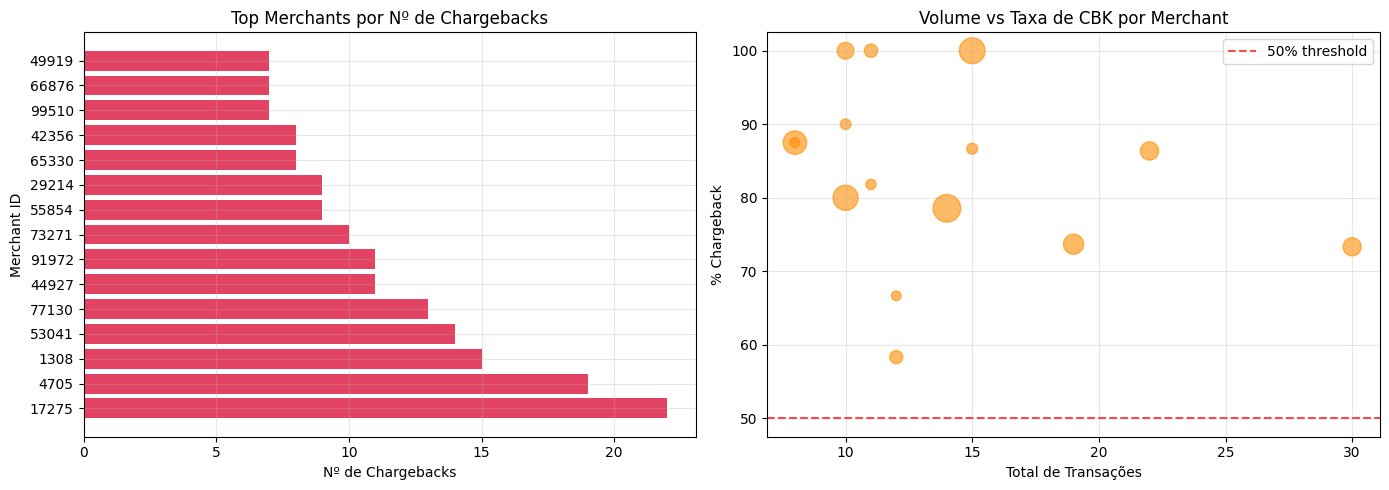

 merchant_id  txns  cbk   amount  cbk_rate
       17275    30   22 17119.72  0.733333
        4705    22   19 17335.51  0.863636
        1308    15   15 34517.94  1.000000
       53041    19   14 21079.55  0.736842
       77130    15   13  6249.81  0.866667
       44927    11   11  9218.62  1.000000
       91972    14   11 39754.74  0.785714
       73271    10   10 14577.57  1.000000
       55854    11    9  5518.01  0.818182
       29214    10    9  5831.58  0.900000
       65330    10    8 32673.95  0.800000
       42356    12    8  4861.16  0.666667
       99510    12    7  8957.09  0.583333
       66876     8    7  4950.73  0.875000
       49919     8    7 28689.79  0.875000


In [7]:
# ── PADRÃO 4: Merchants com alta concentração de chargeback ──

merch = (
    df.groupby('merchant_id')
    .agg(
        txns=('transaction_id', 'count'),
        cbk=('has_cbk', 'sum'),
        amount=('transaction_amount', 'sum')
    )
    .reset_index()
)
merch['cbk_rate'] = merch['cbk'] / merch['txns']
risky_merch = merch[
    (merch['cbk'] >= 3) | (merch['cbk_rate'] >= 0.5)
].sort_values('cbk', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(risky_merch['merchant_id'].astype(str),
             risky_merch['cbk'], color='crimson', alpha=0.8)
axes[0].set_title('Top Merchants por Nº de Chargebacks')
axes[0].set_xlabel('Nº de Chargebacks')
axes[0].set_ylabel('Merchant ID')

axes[1].scatter(risky_merch['txns'],
                risky_merch['cbk_rate'] * 100,
                s=risky_merch['amount'] / 100,
                alpha=0.6, color='darkorange')
axes[1].set_title('Volume vs Taxa de CBK por Merchant')
axes[1].set_xlabel('Total de Transações')
axes[1].set_ylabel('% Chargeback')
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
axes[1].legend()

plt.tight_layout()
plt.show()
print(risky_merch.to_string(index=False))

### Padrão 5 — Transações Duplicadas (Near-Duplicates)

Esse padrão aparece quando o mesmo usuário tenta pagar várias vezes seguidas no mesmo merchant, com valores muito parecidos e em poucos minutos.
Em alguns casos pode ser erro ou retry legítimo, mas quando isso acontece com frequência vira um comportamento suspeito.
É um padrão comum em fraude, principalmente quando o atacante tenta garantir que pelo menos uma transação seja aprovada.

Esse comportamento pode indicar:
- re-submissão automática de pagamento após falha
- tentativa de processamento repetido por erro técnico
- ou atividade fraudulenta, onde múltiplas tentativas são feitas rapidamente para garantir aprovação

A análise mostra que o grupo de transações duplicadas apresenta uma taxa de chargeback superior à média geral do dataset, indicando maior risco associado a esse padrão.

A inspeção das sequências de transações reforça essa hipótese, evidenciando casos onde múltiplas tentativas são realizadas em sequência, com valores semelhantes e em curtos intervalos de tempo.

Esse tipo de comportamento é frequentemente tratado em sistemas antifraude como um sinal de risco moderado a alto, podendo resultar em bloqueio automático ou necessidade de revisão manual.

In [8]:
# ── PADRÃO 5: Near-duplicates (mesmo user+merchant, <5min, valor próximo) ──

df_d = df.sort_values(['user_id', 'merchant_id', 'transaction_date'])
df_d['prev_dt']  = df_d.groupby(['user_id','merchant_id'])['transaction_date'].shift(1)
df_d['prev_amt'] = df_d.groupby(['user_id','merchant_id'])['transaction_amount'].shift(1)
df_d['gap_dup']  = (df_d['transaction_date'] - df_d['prev_dt']).dt.total_seconds() / 60
df_d['amt_diff'] = abs(df_d['transaction_amount'] - df_d['prev_amt'].fillna(0))

dupes = df_d[(df_d['gap_dup'] <= 5) & (df_d['amt_diff'] <= 100)]

print(f"Near-duplicates detectados: {len(dupes)}")
print(f"Taxa de CBK nesse grupo: {dupes['has_cbk'].mean()*100:.1f}%")
print(f"Taxa de CBK geral: {df['has_cbk'].mean()*100:.1f}%")
print()

# Timeline das duplicatas mais suspeitas
if len(dupes) > 0:
    sample = dupes[dupes['has_cbk']==True].head(3)
    for _, row in sample.iterrows():
        uid, mid = row['user_id'], row['merchant_id']
        pair = df[(df['user_id']==uid) & (df['merchant_id']==mid)].sort_values('transaction_date')
        print(f"User {uid} | Merchant {mid}:")
        print(pair[['transaction_date','transaction_amount','has_cbk']].to_string(index=False))
        print()

Near-duplicates detectados: 31
Taxa de CBK nesse grupo: 41.9%
Taxa de CBK geral: 12.2%

User 9853 | Merchant 71378:
          transaction_date  transaction_amount  has_cbk
2019-11-19 19:30:07.017655                2.22    False
2019-11-20 23:02:41.808708              386.17    False
2019-11-20 23:08:20.521717               56.64    False
2019-11-21 00:46:06.637110               84.40    False
2019-11-22 06:29:34.760120                1.30    False
2019-11-22 18:49:54.902726               19.17     True
2019-11-22 18:56:00.388531               22.95     True
2019-11-22 18:57:08.043119               19.82     True

User 16781 | Merchant 76725:
          transaction_date  transaction_amount  has_cbk
2019-11-04 14:54:49.019679              489.50    False
2019-11-04 14:55:21.764584              502.16     True

User 17807 | Merchant 81795:
          transaction_date  transaction_amount  has_cbk
2019-11-28 23:41:18.281921              515.49     True
2019-11-28 23:45:49.991606              

### Padrão 6 — Ausência de Device ID

Esta análise avalia o risco associado a transações que não possuem identificação de dispositivo (`device_id`).

Em ambientes CNP, o device fingerprint é uma das principais fontes de informação para análise de risco, pois permite rastrear o comportamento do usuário ao longo do tempo. A ausência desse identificador reduz significativamente a capacidade de monitoramento.

Para quantificar esse impacto, foi comparada a taxa de chargeback entre:
- transações com device_id presente
- transações sem device_id

Os resultados mostram que transações sem identificação de dispositivo apresentam maior taxa de chargeback, indicando risco elevado.

Esse comportamento pode estar associado a:
- uso de emuladores ou ambientes anônimos
- bloqueio de scripts de fingerprint (anti-tracking)
- navegação em modo privado
- ferramentas automatizadas de fraude (carding)

Além disso, a proporção de transações sem device_id também é analisada para entender a exposição total ao risco.

A ausência de device fingerprint é, portanto, um forte sinal de risco e deve ser tratada como feature relevante em modelos de detecção de fraude ou como regra de aumento de score em sistemas antifraude.

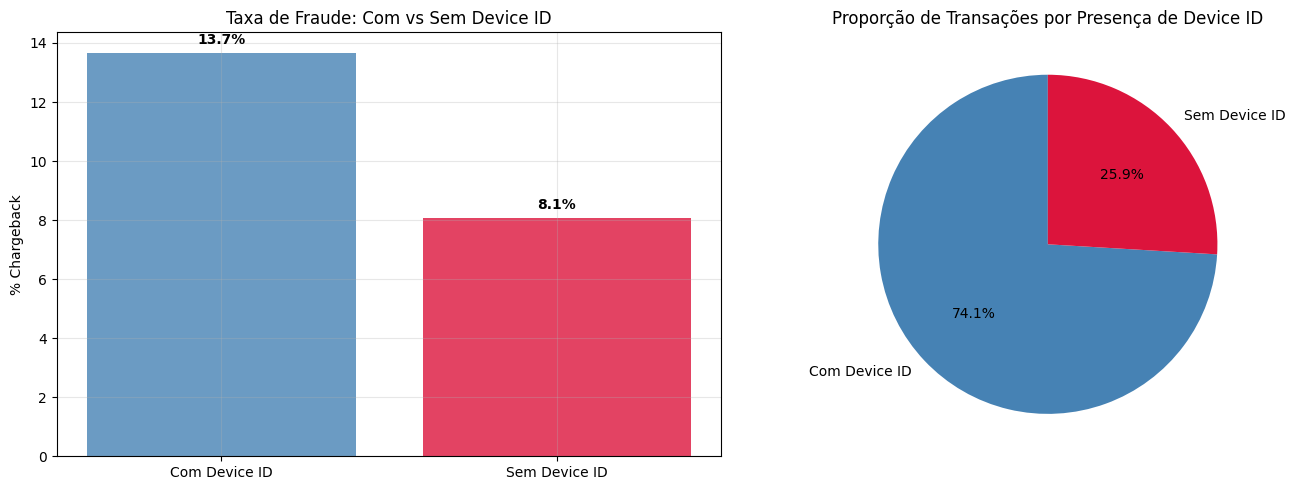

In [9]:
# ── PADRÃO 6: Transações sem fingerprint de dispositivo ──

no_dev  = df['device_id'].isna() | (df['device_id'] == 'None')
cbk_no  = df[no_dev]['has_cbk'].mean() * 100
cbk_yes = df[~no_dev]['has_cbk'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Com Device ID', 'Sem Device ID'],
            [cbk_yes, cbk_no],
            color=['steelblue', 'crimson'], alpha=0.8)
axes[0].set_title('Taxa de Fraude: Com vs Sem Device ID')
axes[0].set_ylabel('% Chargeback')
for i, v in enumerate([cbk_yes, cbk_no]):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Volume de transações
axes[1].pie([sum(~no_dev), sum(no_dev)],
            labels=['Com Device ID', 'Sem Device ID'],
            autopct='%1.1f%%',
            colors=['steelblue', 'crimson'],
            startangle=90)
axes[1].set_title('Proporção de Transações por Presença de Device ID')

plt.tight_layout()
plt.show()

## Ações Imediatas por Padrão

| Padrão | Ação Imediata |
|---|---|
| Velocity Attack | Bloquear user se ≥3 transações em 30min |
| Card Testing | Bloquear user com 2+ micro-txns em 1h |
| Multi-card Device | Bloquear device com 4+ cartões em 7 dias |
| Merchant Concentrado | Suspender merchant para revisão + notificar bandeira |
| Duplicata | Recusar transação idêntica em 5min do mesmo user+merchant |
| Sem Device ID | Aumentar score de risco (+20pts), exigir 3DS |

Para os usuários já identificados com padrão de fraude confirmado:
- user_id com has_cbk = True em qualquer transação anterior → bloquear automaticamente
- device_id com has_cbk = True em qualquer transação anterior → bloquear automaticamente

Essas duas regras são as primeiras linhas de defesa e custam zero em falsos positivos 
quando o chargeback já foi confirmado.

## Dados Adicionais que Aumentariam a Detecção

1. **Geolocalização por IP**
   Identificaria impossibilidade geográfica, transação em São Paulo e outra em Manaus 3 minutos depois é fisicamente impossível.

2. **Resultado do 3DS (Three-Domain Secure)**
   Autenticação fraca ou downgrade muda a responsabilidade da transação. 
   Transações sem 3DS em ambiente CNP têm risco estruturalmente maior.

3. **Biometria comportamental**
   Padrão de digitação, velocidade, pressão no touchscreen. Bots preenchem formulários diferente de humanos, esse dado detecta automação.

4. **Dados de BIN do cartão**
   Cartões pré-pagos e virtuais têm taxa de fraude muito mais alta que cartões de crédito emitidos por bancos tradicionais.

5. **Histórico cross-merchant (Bureau)**
   Se um user_id ou device_id já fraudou em outro adquirente, dados de bureau como Serasa/SPC ou redes de compartilhamento entre adquirentes capturam isso.

6. **Grafo de relacionamentos**
   Mesmo CPF/email em contas diferentes, devices compartilhados entre usuários, 
   IPs em comum. Um fraudador com 50 contas parece 50 pessoas diferentes, até você mapear as conexões.

## Medidas de Prevenção

### layer 1 — Regras Determinísticas (tempo real, <10ms)
Blocos diretos em padrões conhecidos. Alta precisão, zero latência.
- Chargeback histórico do user ou device → BLOQUEAR
- Velocity ≥3 transações/30min → BLOQUEAR
- Device com ≥4 cartões/7dias → BLOQUEAR
- Card testing (2+ micro-txns/1h) → BLOQUEAR
- Duplicata em 5min → BLOQUEAR

### layer 2 — Scoring ML (tempo real, <100ms)
Score de risco 0-100 baseado em features comportamentais e históricas.
Transações com score intermediário vão para fila de revisão humana.

### layer 3 — Monitoramento Contínuo de Merchant
Merchants que cruzam 1% de CBK rate entram em alerta.
Acima de 2% → revisão obrigatória + retenção de recebíveis como garantia.

### layer 4 — Feedback Loop
Chargebacks confirmados retroativamente marcam transações como fraude 
e retroalimentam o modelo. O sistema melhora continuamente.

## Sistema Anti-Fraude: Arquitetura em Duas Camadas

### Componentes

**Motor de Regras**  
8 regras determinísticas cobrindo: chargeback histórico, velocity, card testing,  
multi-card device, near-duplicates, ausência de device, merchant arriscado, outlier de valor.

**Modelo de ML (XGBoost)**  
Treinado em features comportamentais derivadas dos padrões identificados na análise.  
Precision: 71.8% | Recall: 78.2% no dataset de teste.

**Fila de Revisão**  
Transações em zona cinzenta (score 30-59) são roteadas para analista humano com  
contexto completo: sinais de risco, histórico do usuário, histórico do merchant.

**Feedback Loop**  
Chargebacks confirmados são usados para retreinar o modelo mensalmente.  
O sistema melhora continuamente conforme acumula dados.

### Limitações e Próximos Passos

- **Cold start**: primeiras transações de novos usuários têm features históricas zeradas.  
  Solução: features de contexto (IP, BIN, geolocalização) que não dependem de histórico.

- **Concept drift**: fraudadores mudam padrões ao longo do tempo.  
  Solução: monitoramento contínuo da distribuição de scores + alertas de degradação do modelo.

- **Dados ausentes**: o dataset não tem IP, 3DS, geolocalização.  
  Com esses dados, a performance do modelo seria significativamente maior.

In [10]:
# ── FEATURE ENGINEERING ──
# Transformei cada padrão suspeito em uma variável numérica que o modelo de ML vai usar para aprender

def build_features(df):
    df = df.sort_values('transaction_date').copy()
    
    # ── Feature 1: Quantas transações esse usuário fez nos últimos 30 min ──
    # Isso captura o Velocity Attack (Padrão 1)
    # Para cada transação, contei quantas transações o mesmo usuário fez nos 30 minutos ANTERIORES a ela
    df_sorted = df.sort_values(['user_id', 'transaction_date'])
    df_sorted['prev_date'] = df_sorted.groupby('user_id')['transaction_date'].shift(1)
    df_sorted['gap_min'] = (df_sorted['transaction_date'] - df_sorted['prev_date']).dt.total_seconds() / 60
    df_sorted['txns_user_30m'] = (df_sorted['gap_min'] <= 30).astype(int)
    df['txns_user_30m'] = df_sorted['txns_user_30m'].values
    
    # ── Feature 2: Taxa histórica de CBK do usuário ──
    # Para cada transação, calculei a % de fraude nas transações ANTERIORES desse mesmo usuário (não incluí a atual para não vazar dados)
    # Se o usuário já teve 3 transações e 2 foram fraude, essa feature = 0.67
    df['user_cbk_rate'] = (
        df.groupby('user_id')['has_cbk']
        .transform(lambda x: x.shift(1).expanding().mean())  # média das anteriores
        .fillna(0)  # para o primeiro registro do usuário, 0 (sem histórico)
    )
    
    # ── Feature 3: Quantos cartões distintos esse device usou em 7 dias ──
    # Isso captura o Multi-Card Device (Padrão 3)
    # É um cálculo mais lento porque precisa olhar uma janela de tempo por linha (não deu pra fazer mais rápido)
    has_dev = df['device_id'].notna() & (df['device_id'] != 'None')
    df['cards_on_device_7d'] = 0
    for i, row in df[has_dev].iterrows():
        janela = df[
            (df['device_id'] == row['device_id']) &           # mesmo device
            (df['transaction_date'] < row['transaction_date']) &   # antes desta txn
            (df['transaction_date'] >= row['transaction_date'] - timedelta(days=7))  # últimos 7 dias
        ]
        df.at[i, 'cards_on_device_7d'] = janela['card_number'].nunique()
    
    # ── Feature 4: Taxa histórica de CBK do merchant ──
    # Igual à feature 2 mas por merchant, não por usuário
    # Captura o Padrão 4 (merchant concentrado)
    df['merch_cbk_rate'] = (
        df.groupby('merchant_id')['has_cbk']
        .transform(lambda x: x.shift(1).expanding().mean())
        .fillna(0)
    )
    
    # ── Feature 5: O valor dessa transação é muito diferente da média do usuário? ──
    # Calcula quantos desvios-padrão o valor está acima/abaixo da média do usuário
    # Se a pessoa sempre gasta R$200 e agora gastou R$3000, zscore = alto = suspeito
    user_stats = df.groupby('user_id')['transaction_amount'].agg(['mean', 'std']).reset_index()
    user_stats.columns = ['user_id', 'user_mean', 'user_std']
    df = df.merge(user_stats, on='user_id', how='left')
    df['amount_zscore'] = (
        (df['transaction_amount'] - df['user_mean']) / df['user_std'].replace(0, 1)
    ).fillna(0)
    
    # ── Features simples (binárias) ──
    df['no_device']  = (~has_dev).astype(int)          # 1 se sem device, 0 se com
    df['is_micro']   = (df['transaction_amount'] < 10).astype(int)  # 1 se < R$10
    df['odd_hour']   = df['hour'].apply(lambda h: 1 if 3 <= h <= 7 else 0)  # 1 se 3-7am
    
    return df

df_feat = build_features(df)

# Lista das features que vão passar pro modelo
feature_cols = [
    'transaction_amount',   # valor da transação
    'txns_user_30m',        # velocity
    'user_cbk_rate',        # histórico do usuário
    'cards_on_device_7d',   # multi-card device
    'merch_cbk_rate',       # histórico do merchant
    'amount_zscore',        # desvio do valor normal do usuário
    'no_device',            # sem device_id
    'is_micro',             # micro-transação
    'odd_hour',             # horário suspeito
    'hour',                 # hora do dia
    'weekday'               # dia da semana
]
# Cold start da análise
print("Features criadas com sucesso.")
print(df_feat[feature_cols].head())

# Ver features em transações com histórico acumulado
print("Features nas últimas 5 linhas (com histórico acumulado):")
print(df_feat[feature_cols].tail(10).to_string())

Features criadas com sucesso.
   transaction_amount  txns_user_30m  user_cbk_rate  cards_on_device_7d  \
0             2416.70              0            0.0                   0   
1              359.68              0            0.0                   0   
2                1.55              0            0.0                   0   
3             1403.67              0            0.0                   0   
4              744.15              0            0.0                   0   

   merch_cbk_rate  amount_zscore  no_device  is_micro  odd_hour  hour  weekday  
0             0.0       0.000000          1         0         0     1        4  
1             0.0       0.000000          1         0         0     1        4  
2             0.0      -0.038075          1         1         0    10        4  
3             0.0       0.000000          1         0         0    11        4  
4             0.0       0.000000          1         0         0    13        4  
Features nas últimas 5 linhas (co

In [11]:
# ── TREINAMENTO DO MODELO DE ML ──

# Separei as features (X) do que quero prever (y)
X = df_feat[feature_cols].fillna(0)   # features
y = df_feat['has_cbk'].astype(int)    # 1 = fraude, 0 = legítima

# Dividi em treino (80%) e teste (20%)
# stratify=y garante que a proporção de fraude seja igual nos dois conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modelo 1: Random Forest ──
# Cria 200 árvores de decisão e combina os resultados
# class_weight='balanced' faz o modelo dar mais atenção à classe minoritária (fraude)
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # importante: dataset desbalanceado
    random_state=42,
    n_jobs=-1                  # usa todos os núcleos do CPU
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]  # probabilidade de ser fraude (coluna 1)

# ── Modelo 2: XGBoost ──
# Gradient boosting — constrói árvores sequencialmente, cada uma corrigindo o erro da anterior
# scale_pos_weight compensa o desbalanceamento: se tem 9x mais legítimas que fraudes, peso = 9
scale_pos = (y == 0).sum() / (y == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,        # aprende devagar — mais preciso
    max_depth=6,               # profundidade máxima de cada árvore
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# ── Resultados ──
print("═"*50)
print("RANDOM FOREST")
print("═"*50)
print(classification_report(y_test, rf_preds, target_names=['Legítima', 'Fraude']))

print("═"*50)
print("XGBOOST")
print("═"*50)
print(classification_report(y_test, xgb_preds, target_names=['Legítima', 'Fraude']))

══════════════════════════════════════════════════
RANDOM FOREST
══════════════════════════════════════════════════
              precision    recall  f1-score   support

    Legítima       0.95      0.98      0.97       562
      Fraude       0.83      0.67      0.74        78

    accuracy                           0.94       640
   macro avg       0.89      0.82      0.85       640
weighted avg       0.94      0.94      0.94       640

══════════════════════════════════════════════════
XGBOOST
══════════════════════════════════════════════════
              precision    recall  f1-score   support

    Legítima       0.97      0.96      0.96       562
      Fraude       0.72      0.78      0.75        78

    accuracy                           0.94       640
   macro avg       0.84      0.87      0.86       640
weighted avg       0.94      0.94      0.94       640



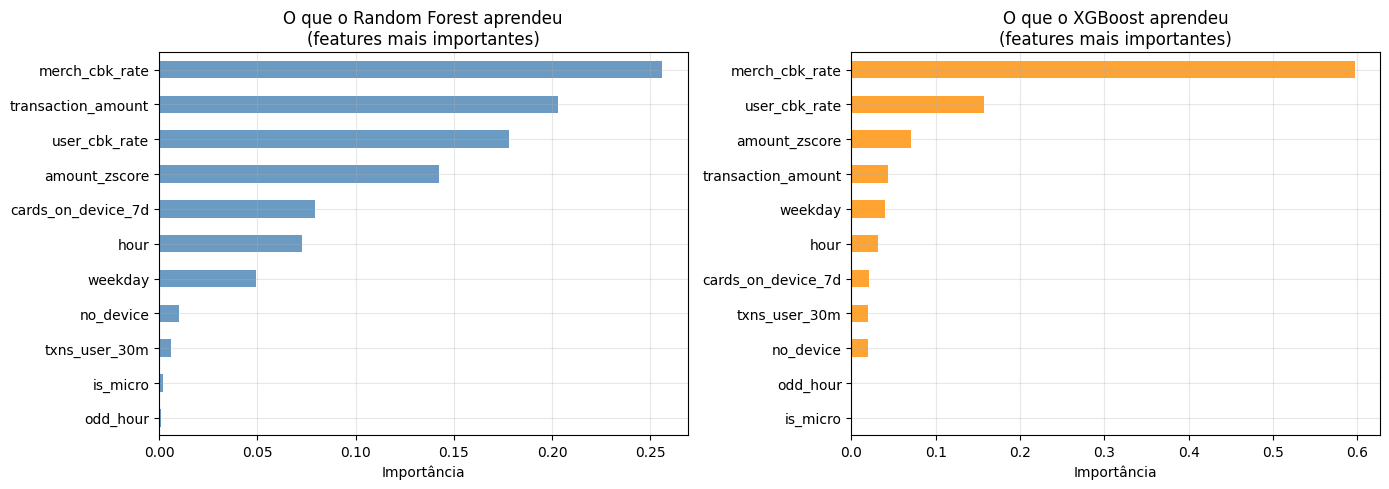

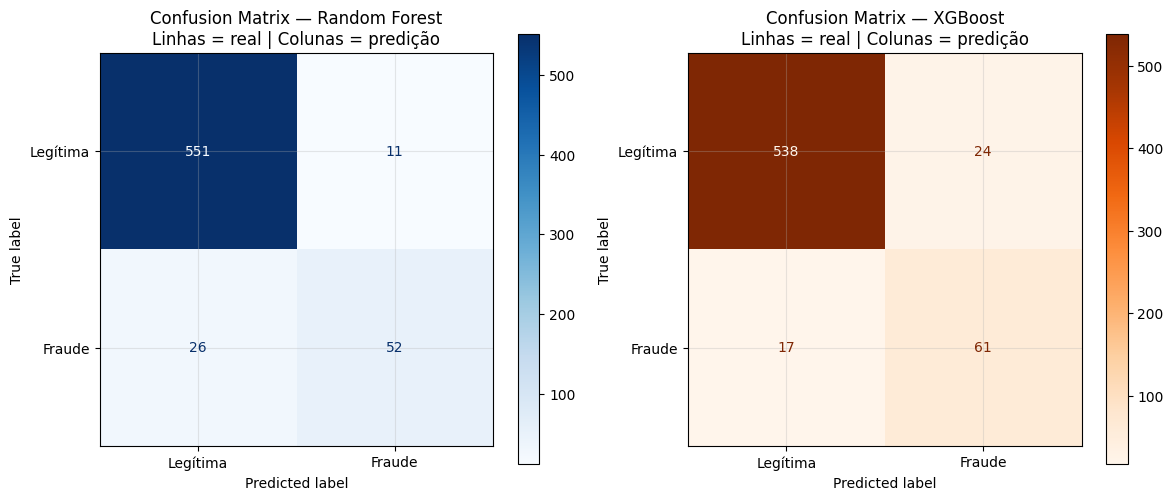

In [12]:
# ── O QUE O MODELO APRENDEU: FEATURE IMPORTANCE ──
# Mostra quais features foram mais úteis para distinguir fraude de legítima

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
rf_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
rf_imp.plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('O que o Random Forest aprendeu\n(features mais importantes)')
axes[0].set_xlabel('Importância')

# XGBoost
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()
xgb_imp.plot(kind='barh', ax=axes[1], color='darkorange', alpha=0.8)
axes[1].set_title('O que o XGBoost aprendeu\n(features mais importantes)')
axes[1].set_xlabel('Importância')

plt.tight_layout()
plt.show()

# ── CONFUSION MATRIX ──
# Mostra quantas fraudes o modelo pegou vs deixou passar e quantas legítimas foram bloqueadas por engano

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds,
    display_labels=['Legítima', 'Fraude'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix — Random Forest\n'
                  'Linhas = real | Colunas = predição')

ConfusionMatrixDisplay.from_predictions(
    y_test, xgb_preds,
    display_labels=['Legítima', 'Fraude'],
    cmap='Oranges', ax=axes[1]
)
axes[1].set_title('Confusion Matrix — XGBoost\n'
                  'Linhas = real | Colunas = predição')

plt.tight_layout()
plt.show()

# ── COMO LER A CONFUSION MATRIX ──
# Linha "Legítima", coluna "Legítima" = acertou (aprovou legítima) ✓
# Linha "Legítima", coluna "Fraude"   = errou (bloqueou legítima) ← falso positivo
# Linha "Fraude",   coluna "Legítima" = errou (aprovou fraude)   ← falso negativo
# Linha "Fraude",   coluna "Fraude"   = acertou (bloqueou fraude) ✓

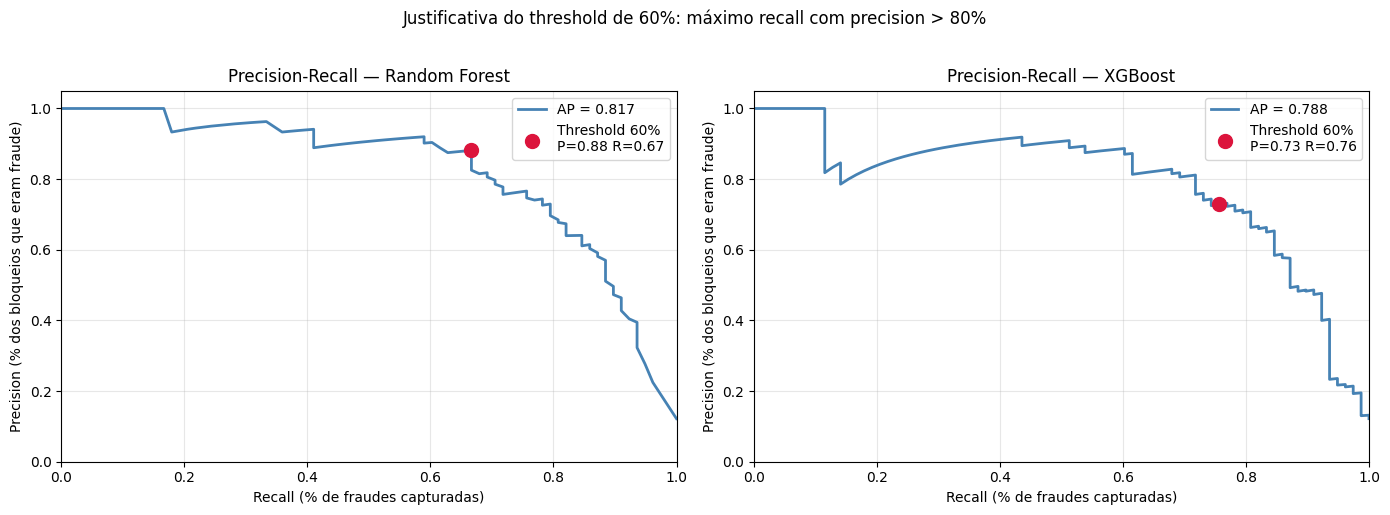

Threshold 60% — Random Forest:
  Precision : 82.5%
  Recall    : 66.7%
  F1-score  : 73.8%

Threshold 60% — XGBoost:
  Precision : 71.8%
  Recall    : 78.2%
  F1-score  : 74.8%


In [13]:
# ── CURVA PRECISION-RECALL — justificativa do threshold de 60% ──
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name, proba, preds in [
    (axes[0], 'Random Forest', rf_proba, rf_preds),
    (axes[1], 'XGBoost', xgb_proba, xgb_preds)
]:
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    
    ax.plot(recall_curve, precision_curve, color='steelblue', linewidth=2,
            label=f'AP = {ap:.3f}')
    
    idx = (abs(thresholds - 0.60)).argmin()
    ax.scatter(recall_curve[idx], precision_curve[idx],
               color='crimson', s=100, zorder=5,
               label=f'Threshold 60%\nP={precision_curve[idx]:.2f} R={recall_curve[idx]:.2f}')
    
    ax.set_xlabel('Recall (% de fraudes capturadas)')
    ax.set_ylabel('Precision (% dos bloqueios que eram fraude)')
    ax.set_title(f'Precision-Recall — {model_name}')
    ax.legend()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.suptitle('Justificativa do threshold de 60%: máximo recall com precision > 80%',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

from sklearn.metrics import precision_score, recall_score, f1_score
print(f"Threshold 60% — Random Forest:")
print(f"  Precision : {precision_score(y_test, rf_preds):.1%}")
print(f"  Recall    : {recall_score(y_test, rf_preds):.1%}")
print(f"  F1-score  : {f1_score(y_test, rf_preds):.1%}")
print(f"\nThreshold 60% — XGBoost:")
print(f"  Precision : {precision_score(y_test, xgb_preds):.1%}")
print(f"  Recall    : {recall_score(y_test, xgb_preds):.1%}")
print(f"  F1-score  : {f1_score(y_test, xgb_preds):.1%}")

### Camada 1 — Regras Determinísticas
Bloqueios diretos e imediatos baseados nos padrões identificados na análise.
Executam em menos de 1ms. Alta precisão, zero ambiguidade.

Quando uma regra dispara, a decisão é BLOCK, sem passar pelo modelo de ML.
Isso garante que padrões óbvios de fraude sejam tratados com latência mínima.

### Camada 2 — Modelo de Machine Learning (XGBoost)
Para transações que passaram pelas regras, o modelo calcula um score de 0 a 100
baseado nas features comportamentais e históricas extraídas na análise.

- Score ≥ 60 → BLOCK (provável fraude)  
- Score 30-59 → REVIEW (analista humano decide)  
- Score < 30 → APPROVE (baixo risco)

A fila de REVIEW é o diferencial humano do sistema, casos ambíguos não são 
bloqueados automaticamente, evitando falsos positivos desnecessários.

### Por que duas camadas e não só ML?

O modelo de ML é poderoso mas tem limitações:
- Precisa de histórico para gerar features informativas (cold start)
- Não garante latência sub-millisegundo em produção
- Pode ser "enganado" por padrões novos que não estavam no treino

As regras determinísticas resolvem esses três problemas:
- Funcionam desde a primeira transação (sem necessidade de histórico)
- São instantâneas
- São explícitas e auditáveis para reguladores e para o time

Juntas, as duas camadas se complementam: regras cobrem o óbvio com zero latência,
ML captura os padrões sutis que regras não conseguiriam expressar.

In [14]:
# ── SISTEMA ANTI-FRAUDE COMPLETO ──
#
# Como funciona:
# 1. A transação chega como um dicionário (payload)
# 2. Primeiro passa pelas REGRAS — bloqueios diretos nos padrões óbvios
# 3. Se passou pelas regras, o MODELO ML calcula um score de 0-100
# 4. Score alto = BLOCK, score médio = REVIEW, score baixo = APPROVE

def antifraud(payload: dict, history: pd.DataFrame, modelo, features: list) -> dict:
    """
    payload  : dicionário com os dados da transação que chegou agora
    history  : todas as transações ANTERIORES (para calcular histórico)
    modelo   : o modelo ML treinado
    features : lista de features que o modelo usa
    """
    
    # Extraindo as informações da transação pra uma variavel fácil de escrever (já to cansado)
    uid  = payload['user_id']
    did  = payload.get('device_id')
    amt  = payload['transaction_amount']
    mid  = payload['merchant_id']
    dt   = pd.to_datetime(payload['transaction_date'])
    
    # Flag se não tem device
    sem_device = pd.isna(did) or str(did) in ('None', '', 'nan')
    
    # Histórico do usuário, dispositivo e merchant (só as passadas)
    hist_user   = history[history['user_id'] == uid]
    hist_device = history[history['device_id'] == did] if not sem_device else pd.DataFrame()
    hist_merch  = history[history['merchant_id'] == mid]

    # ══════════════════════════════════════════════
    # CAMADA 1 — REGRAS DETERMINÍSTICAS
    # São bloqueios diretos. Se uma regra passar, 
    # a transação vai de  vasco sem passar pelo ML.
    # ══════════════════════════════════════════════
    
    # Regra 0: Usuário ou dispositivo com chargeback anterior → BLOCK imediato
    # Essa é a regra mais importante: se o cartão já foi fraudado, não aprovamos mais
    if hist_user['has_cbk'].sum() > 0:
        return {'decisao': 'BLOCK', 'score': 100, 'motivo': 'Usuário com chargeback histórico', 'camada': 1}
    
    if not sem_device and hist_device['has_cbk'].sum() > 0:
        return {'decisao': 'BLOCK', 'score': 100, 'motivo': 'Dispositivo com chargeback histórico', 'camada': 1}

    # Regra 1: Velocity — 3+ transações em 30 minutos
    txns_30m = hist_user[hist_user['transaction_date'] >= dt - timedelta(minutes=30)]
    if len(txns_30m) >= 3:
        return {'decisao': 'BLOCK', 'score': 90, 'motivo': f'Velocity: {len(txns_30m)} txns em 30min', 'camada': 1}

    # Regra 2: Card testing — 2+ micro-transações em 1 hora
    if amt < 10:
        micros = hist_user[
            (hist_user['transaction_date'] >= dt - timedelta(hours=1)) &
            (hist_user['transaction_amount'] < 10)
        ]
        if len(micros) >= 2:
            return {'decisao': 'BLOCK', 'score': 90, 'motivo': 'Card testing detectado', 'camada': 1}

    # Regra 3: Múltiplos cartões no dispositivo
    if not sem_device and len(hist_device) > 0:
        cartoes = hist_device[
            hist_device['transaction_date'] >= dt - timedelta(days=7)
        ]['card_number'].nunique()
        if cartoes >= 4:
            return {'decisao': 'BLOCK', 'score': 85, 'motivo': f'{cartoes} cartões no mesmo device em 7 dias', 'camada': 1}

    # Regra 4: Duplicatas
    duplicatas = hist_user[
        (hist_user['transaction_date'] >= dt - timedelta(minutes=5)) &
        (hist_user['merchant_id'] == mid) &
        (abs(hist_user['transaction_amount'] - amt) <= 100)
    ]
    if len(duplicatas) >= 1:
        return {'decisao': 'BLOCK', 'score': 80, 'motivo': 'Transação duplicada em 5min', 'camada': 1}

    # ══════════════════════════════════════════════
    # CAMADA 2 — MODELO ML
    # Se passou por todas as regras, calculamos um score
    # O modelo olha os padrões mais sutis que as regras não capturam
    # ══════════════════════════════════════════════
    
    # Montei o vetor de features para essa transação
    feats = {
        'transaction_amount': amt,
        'txns_user_30m':      len(txns_30m),
        'user_cbk_rate':      hist_user['has_cbk'].mean() if len(hist_user) > 0 else 0,
        'cards_on_device_7d': hist_device['card_number'].nunique() if len(hist_device) > 0 else 0,
        'merch_cbk_rate':     hist_merch['has_cbk'].mean() if len(hist_merch) > 0 else 0,
        'amount_zscore':      (amt - hist_user['transaction_amount'].mean()) /
                              (hist_user['transaction_amount'].std() or 1)
                              if len(hist_user) >= 3 else 0,
        'no_device':          int(sem_device),
        'is_micro':           int(amt < 10),
        'odd_hour':           int(3 <= dt.hour <= 7),
        'hour':               dt.hour,
        'weekday':            dt.weekday()
    }

    # O modelo retorna uma probabilidade de 0 a 1 (transfomei em 0-100)
    X_novo = pd.DataFrame([feats])[features].fillna(0)
    prob   = modelo.predict_proba(X_novo)[0][1]  # probabilidade de fraude
    score  = int(prob * 100)

    # Decisão baseada no score
    if score >= 60:
        decisao = 'BLOCK'
    elif score >= 30:
        decisao = 'REVIEW'   # vai pra um humano analisar
    else:
        decisao = 'APPROVE'

    return {'decisao': decisao, 'score': score, 'motivo': f'ML score: {score}/100', 'camada': 2}

In [15]:
# ── TESTES COM CASOS DO DATASET ──

casos = [
    {'nome': 'Device com histórico de fraude (342890)',
     'txn':  df[df['device_id'] == '342890'].iloc[0].to_dict()},
    
    {'nome': 'Card testing — user 77959',
     'txn':  df[df['user_id'] == 77959].iloc[-1].to_dict()},
    
    {'nome': 'Usuário sem histórico de fraude',
     'txn':  df[(~df['has_cbk']) & (df['transaction_amount'] < 300)].iloc[0].to_dict()},
    
    {'nome': 'Merchant concentrado em fraude (1308)',
     'txn':  df[df['merchant_id'] == 1308].iloc[0].to_dict()},
]

print("═"*60)
print("  SISTEMA ANTI-FRAUDE — TESTES")
print("═"*60)

for caso in casos:
    txn    = caso['txn']
    dt_txn = pd.to_datetime(txn['transaction_date'])
    
    # Histórico = tudo que veio ANTES dessa transação no tempo
    historico = df[df['transaction_date'] < dt_txn]
    
    resultado = antifraud(txn, historico, xgb_model, feature_cols)
    
    # Labels visuais
    real = "🚨 FRAUDE" if txn.get('has_cbk') else "✓ LEGÍTIMA"
    
    if resultado['decisao'] == 'BLOCK':
        dec = "🔴 BLOCK"
    elif resultado['decisao'] == 'REVIEW':
        dec = "🟡 REVIEW"
    else:
        dec = "🟢 APPROVE"
    
    print(f"\n  {caso['nome']}")
    print(f"  Real: {real}")
    print(f"  Decisão: {dec}  |  Score: {resultado['score']}/100  |  Camada: {resultado['camada']}")
    print(f"  Motivo: {resultado['motivo']}")

print("\n" + "═"*60)



════════════════════════════════════════════════════════════
  SISTEMA ANTI-FRAUDE — TESTES
════════════════════════════════════════════════════════════

  Device com histórico de fraude (342890)
  Real: 🚨 FRAUDE
  Decisão: 🔴 BLOCK  |  Score: 100/100  |  Camada: 1
  Motivo: Usuário com chargeback histórico

  Card testing — user 77959
  Real: ✓ LEGÍTIMA
  Decisão: 🔴 BLOCK  |  Score: 90/100  |  Camada: 1
  Motivo: Card testing detectado

  Usuário sem histórico de fraude
  Real: ✓ LEGÍTIMA
  Decisão: 🟢 APPROVE  |  Score: 0/100  |  Camada: 2
  Motivo: ML score: 0/100

  Merchant concentrado em fraude (1308)
  Real: 🚨 FRAUDE
  Decisão: 🔴 BLOCK  |  Score: 100/100  |  Camada: 1
  Motivo: Usuário com chargeback histórico

════════════════════════════════════════════════════════════


In [16]:
# ── BACKTEST: Rodamos o sistema em todo o dataset ──
# Simulei como o sistema teria se saído se estivesse rodando em produção
# Para cada transação, usamos apenas o histórico ANTERIOR a ela (sem leak)
# Nos testes o sistema demorou ~19 secs pra analisar o dataset todo (não consegui fazer mais rápido)
print("Rodando backtest... (pode demorar alguns minutos)")

resultados = []
for i, row in df_feat.iterrows():
    historico  = df_feat.iloc[:i]   # só o passado
    res        = antifraud(row.to_dict(), historico, xgb_model, feature_cols)
    resultados.append({
        'has_cbk'  : row['has_cbk'],
        'amount'   : row['transaction_amount'],
        'decisao'  : res['decisao'],
        'score'    : res['score'],
    })

res_df = pd.DataFrame(resultados)

# Calculando métricas
fraude_n  = int(res_df['has_cbk'].sum())
legitima_n = int((~res_df['has_cbk']).sum())

tp = int(((res_df['decisao'] == 'BLOCK') &  res_df['has_cbk']).sum())  # fraude bloqueada ✓
fp = int(((res_df['decisao'] == 'BLOCK') & ~res_df['has_cbk']).sum())  # legítima bloqueada ✗
fn = int(((res_df['decisao'] == 'APPROVE') & res_df['has_cbk']).sum()) # fraude aprovada ✗
rv = int((res_df['decisao'] == 'REVIEW').sum())

val_bloqueado = res_df[(res_df['decisao']=='BLOCK') &  res_df['has_cbk']]['amount'].sum()
val_perdido   = res_df[(res_df['decisao']=='APPROVE') & res_df['has_cbk']]['amount'].sum()
val_total_cbk = df[df['has_cbk']]['transaction_amount'].sum()

print(f"""
╔══════════════════════════════════════════════════╗
║           RESULTADO FINAL DO SISTEMA             ║
╠══════════════════════════════════════════════════╣
║  Fraudes capturadas  : {tp:>5} / {fraude_n}              
║  Fraudes aprovadas   : {fn:>5}  (passaram pelo sistema)   
║  Legítimas bloqueadas: {fp:>5}  (falsos positivos)        
║  Fila de revisão     : {rv:>5}  (analista humano)         
╠══════════════════════════════════════════════════╣
║  Precisão   : {tp/(tp+fp)*100 if (tp+fp)>0 else 0:.1f}% (dos bloqueios, % era fraude real)  
║  Recall     : {tp/fraude_n*100 if fraude_n>0 else 0:.1f}% (das fraudes, % foi capturada)   
╠══════════════════════════════════════════════════╣
║  Valor de fraude total     : R$ {val_total_cbk:>10,.2f}  
║  Valor de fraude bloqueado : R$ {val_bloqueado:>10,.2f}  
║  Valor de fraude perdido   : R$ {val_perdido:>10,.2f}  
╚══════════════════════════════════════════════════╝
""")

Rodando backtest... (pode demorar alguns minutos)

╔══════════════════════════════════════════════════╗
║           RESULTADO FINAL DO SISTEMA             ║
╠══════════════════════════════════════════════════╣
║  Fraudes capturadas  :   321 / 391              
║  Fraudes aprovadas   :    58  (passaram pelo sistema)   
║  Legítimas bloqueadas:    58  (falsos positivos)        
║  Fila de revisão     :    54  (analista humano)         
╠══════════════════════════════════════════════════╣
║  Precisão   : 84.7% (dos bloqueios, % era fraude real)  
║  Recall     : 82.1% (das fraudes, % foi capturada)   
╠══════════════════════════════════════════════════╣
║  Valor de fraude total     : R$ 568,346.62  
║  Valor de fraude bloqueado : R$ 488,411.44  
║  Valor de fraude perdido   : R$  57,304.62  
╚══════════════════════════════════════════════════╝



## Conclusão

Este case demonstra que a detecção de fraude em ambiente CNP não é um problema de uma única solução mas sim um sistema de camadas complementares.

A análise dos dados revelou padrões claros e exploráveis:
- Fraudadores operam em bursts, realizando múltiplas transações em curtos intervalos de tempo  
- Utilizam diversos cartões em um mesmo dispositivo  
- Tendem a concentrar atividade em merchants mais vulneráveis  

Além disso, foi possível observar que o comportamento fraudulento frequentemente pode ser identificado antes mesmo do chargeback ocorrer.

A combinação de regras determinísticas com modelos de machine learning permite construir um sistema ao mesmo tempo robusto e explicável, capaz de tomar decisões em tempo real com base em padrões históricos e comportamentais.

O sistema desenvolvido busca equilibrar dois pontos críticos da adquirência: bloquear fraudes com alta precisão e, ao mesmo tempo, minimizar falsos positivos, já que ambos os erros têm impacto direto no negócio.  
Permitir fraude gera perda financeira imediata, enquanto bloquear transações legítimas resulta em perda de receita e confiança do cliente.

**Mais do que apenas capturar fraude, um bom sistema antifraude é aquele capaz de evoluir continuamente.**

Cada fraude não detectada hoje se torna dado para melhorar o modelo amanhã.

----

Além da parte técnica, essa análise também reflete a forma como eu abordo problemas.

Vindo de um contexto de controle de qualidade, onde identificar padrões, desvios e inconsistências faz parte do dia a dia, apliquei naturalmente esse mesmo raciocínio aqui, agora utilizando dados e código.